# 03 · Policy: what happened when the climate bonus ended?

**Business question:** How fast is Sweden shifting to battery-electric cars among private buyers, where is it fastest or slowest and why, and what BEV share is plausible by 2028?

This notebook covers the *why* over time: the effect of ending the climate bonus (klimatbonus) on **8 Nov 2022** on the private BEV share. It answers four questions raised in 01 and 02:
1. Was the change an **immediate drop**, a **change in trend**, or both?
2. How big was the **rush** before the deadline, and how much of the 2023 decline does it explain?
3. Why did **company buyers** behave differently?
4. Did **sparsely populated counties** react more strongly, as 02 suggested?

**Policy timeline** (context only, not taken from the data):
- **Jul 2018:** bonus–malus system introduced.
- **1 Apr 2021:** bonus rules revised, with a higher maximum bonus.
- **8 Nov 2022:** bonus abolished.
- The exact eligibility rules around the deadline (order date vs registration date) matter for how the Nov–Dec 2022 months should be read. They should be checked against the regulation before any month-level claim is cited.

## 1. Setup and design

**Method: interrupted time series (ITS), estimated as a segmented regression.**

$$y_t = \beta_0 + \beta_1 t + \beta_2\,\text{post}_t + \beta_3\,(t - T_0)\,\text{post}_t + \text{month-of-year}_t + \text{transition}_t + \varepsilon_t$$

- $y_t$ = monthly private BEV share (pp), $t$ = months since the start.
- $\beta_1$ = bonus-era trend. $\beta_2$ = **level change** at $T_0$ = Jan 2023. $\beta_3$ = **slope change** after $T_0$.
- **Month-of-year dummies** handle the strong seasonality found in 01 (Sep and Dec spikes). They're estimated on both periods together.
- **Transition months** each get their own dummy. That's equivalent to leaving them out of the trend fit, and their coefficients measure the "rush" above the pre-trend.

**Windows, and the reasons for them:**
- **Pre-period: Apr 2021 – Aug 2022** (17 months). Jan–Mar 2021 is left out: the share was 6–7% and jumped to 20% in April, which coincides with the bonus revision of 1 April 2021. Buyers likely waited, so those months belong to a different policy regime.
- **Transition: Sep – Dec 2022.** The build script's `pull_forward_window` is Sep–Nov. **I add December**, because Dec 2022 was 63% BEV, the highest month in the series and far above a normal December. Leaving it in the post-period would distort the post-bonus level.
- **Post-period: Jan 2023 – Aug 2026** (44 months).

**Standard errors:** Newey–West (HAC, 6 lags) as the main specification, because monthly residuals are autocorrelated. An AR(1)-error model is the main robustness check (section 4).

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import viz
from viz import BLUE, ORANGE, AQUA, RED, INK, INK2, MUTED, GRID, AXIS, GREY_DARK, GREY_LIGHT, SURFACE, PCT
viz.apply_style()
PROC, FIGS = ROOT / "data" / "processed", ROOT / "docs" / "figures"

fact = pd.read_csv(PROC / "fact_registrations_county_monthly.csv", parse_dates=["month"], dtype={"county_code": str})
panel = pd.read_csv(PROC / "county_year_panel.csv", dtype={"county_code": str})

def monthly(df):
    w = df.pivot_table(index="month", columns="fuel_type", values="registrations", aggfunc="sum", fill_value=0)
    return pd.DataFrame({"bev": w["BEV"], "total": w.sum(axis=1)}).assign(share=lambda d: d.bev / d.total)

own = {o: monthly(fact[fact.owner_type == o]) for o in ["private", "company", "dealer"]}
pv = own["private"]

START, T0 = pd.Timestamp("2021-04-01"), pd.Timestamp("2023-01-01")
TRANS = pd.date_range("2022-09-01", "2022-12-01", freq="MS")
LAST = pv.index.max()
print(f"Pre: {START:%b %Y}–Aug 2022 | transition: {TRANS[0]:%b}–{TRANS[-1]:%b %Y} | post: {T0:%b %Y}–{LAST:%b %Y}")

Pre: Apr 2021–Aug 2022 | transition: Sep–Dec 2022 | post: Jan 2023–Aug 2026


## 2. Look at the data around the boundary

Before any model, the raw series. Shares are shown on the left and registration counts on the right, as two separate charts rather than two y-axes on one chart. The grey band marks the transition months.

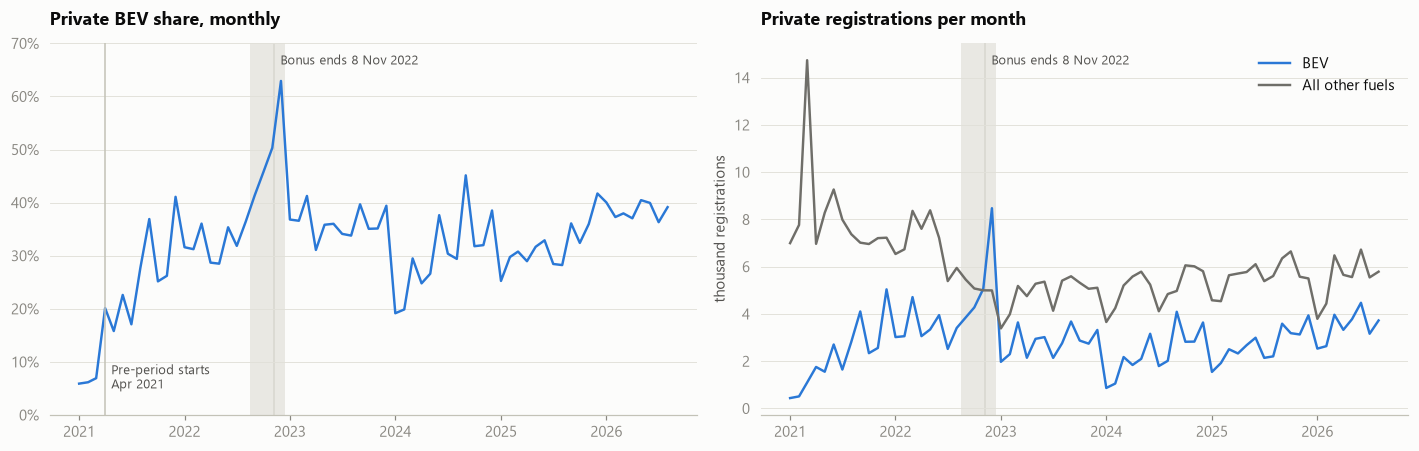

,bev,non_bev,total,share
month,,,,
May 2022,"3,342","8,385","11,727",28.5%
Jun 2022,"3,949","7,221","11,170",35.4%
Jul 2022,"2,519","5,390","7,909",31.8%
Aug 2022,"3,406","5,947","9,353",36.4%
Sep 2022,"3,848","5,457","9,305",41.4%
Oct 2022,"4,276","5,076","9,352",45.7%
Nov 2022,"5,062","4,999","10,061",50.3%
Dec 2022,"8,474","4,995","13,469",62.9%
Jan 2023,"1,973","3,387","5,360",36.8%


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax in axes:
    ax.axvspan(TRANS[0] - pd.Timedelta(days=15), TRANS[-1] + pd.Timedelta(days=15), color=GRID, alpha=0.7, lw=0)
    viz.mark_bonus(ax)
ax = axes[0]
ax.plot(pv.index, pv.share, color=BLUE, lw=1.6)
ax.axvline(START, color=AXIS, lw=1)
ax.annotate("Pre-period starts\nApr 2021", (START, 0.05), xytext=(4, 0), textcoords="offset points", fontsize=8.5, color=INK2)
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, 0.7)
ax.set_title("Private BEV share, monthly")
ax = axes[1]
ax.plot(pv.index, pv.bev / 1000, color=BLUE, lw=1.6, label="BEV")
ax.plot(pv.index, (pv.total - pv.bev) / 1000, color=GREY_DARK, lw=1.6, label="All other fuels")
ax.set_ylabel("thousand registrations")
ax.set_title("Private registrations per month")
ax.legend(loc="upper right")
fig.tight_layout()
viz.save(fig, "03_boundary_raw", FIGS)
plt.show()

win = pv.loc["2022-05":"2023-04"].copy()
win["non_bev"] = win.total - win.bev
win.index = win.index.strftime("%b %Y")
win[["bev", "non_bev", "total", "share"]].style.format({"bev": "{:,.0f}", "non_bev": "{:,.0f}", "total": "{:,.0f}",
                                                       "share": "{:.1%}"}).set_caption("Private registrations around the boundary")

**What the raw data shows**
- The share climbs through autumn 2022 (41% → 46% → 50%) and peaks at **63% in Dec 2022**. Then it **drops to 37% in Jan 2023** and stays in the mid-30s.
- In volume, Dec 2022 is a spike in BEVs (8,474, about 2.5× a normal 2022 month), and **all private buying collapses in early 2023**: Jan 2023 had 5,360 private registrations of all fuels, against 13,469 in December. Part of the 2023 fall in share is a smaller market, as 01 showed. Non-BEV volume also fell.
- The post-2023 share has no visible trend until late 2025, unlike the steep climb before. That's what the segmented regression has to quantify.
- **March 2021** has a spike in non-BEV private registrations (about 14,700, double a normal month), just before the 1 April 2021 rule change. It's consistent with buyers bringing combustion-car purchases forward, and it's a second reason to start the pre-period in April.

## 3. Main model: segmented regression on the private BEV share

The model is fitted as written in section 1. The chart shows the series **seasonally adjusted** with the model's own month effects, so the dots and the fitted trend lines are comparable. The **counterfactual** (the bonus-era trend continued) is drawn as a dashed projection, and **only for 12 months**: see the interpretation for why it isn't extended further.

In [3]:
def its_design(s, start=START, trans=TRANS):
    d = pd.DataFrame({"y": s.loc[start:]})
    d["t"] = np.arange(len(d))
    d["post"] = (d.index >= T0).astype(int)
    d["t_post"] = np.where(d.post == 1, (d.index.year - T0.year) * 12 + d.index.month - T0.month, 0)
    X = d[["t", "post", "t_post"]].astype(float)
    X = X.join(pd.get_dummies(d.index.month, prefix="m", drop_first=True, dtype=float).set_index(d.index))
    for m in trans:
        X[f"tr_{m:%Y_%m}"] = (d.index == m).astype(float)
    return d.y, sm.add_constant(X)

def fit_its(s, errors="hac", **kw):
    y, X = its_design(s, **kw)
    if errors == "hac":
        return sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 6}), y, X
    y, X = y.asfreq("MS"), X.asfreq("MS")
    res = SARIMAX(y, exog=X.drop(columns="const"), order=(1, 0, 0), trend="c").fit(disp=False, maxiter=1000)
    assert res.mle_retvals["converged"], "AR(1) model did not converge"
    return res, y, X

main, y, X = fit_its(pv.share)
K = ["t", "post", "t_post"]
coefs = pd.DataFrame({"estimate (pp)": main.params[K] * 100, "95% CI low": main.conf_int().loc[K, 0] * 100,
                      "95% CI high": main.conf_int().loc[K, 1] * 100, "p-value": main.pvalues[K]},
                     index=K).rename(index={"t": "pre-trend (pp / month)", "post": "level change at Jan 2023",
                                            "t_post": "slope change (pp / month)"})
print(f"n = {int(main.nobs)}, R² = {main.rsquared:.2f}, Durbin–Watson = {durbin_watson(main.resid):.2f}, "
      f"Ljung–Box p (lag 6) = {acorr_ljungbox(main.resid, lags=[6]).lb_pvalue.iloc[0]:.3f}")
print(f"Implied post-bonus trend: {(main.params.t + main.params.t_post) * 100:+.2f} pp / month")
coefs.style.format("{:+.2f}", subset=coefs.columns[:3]).format("{:.3f}", subset=["p-value"])

n = 65, R² = 0.72, Durbin–Watson = 0.77, Ljung–Box p (lag 6) = 0.000
Implied post-bonus trend: +0.07 pp / month


,estimate (pp),95% CI low,95% CI high,p-value
pre-trend (pp / month),+1.00,+0.76,+1.25,0.000
level change at Jan 2023,-9.99,-16.78,-3.20,0.004
slope change (pp / month),-0.93,-1.24,-0.62,0.000


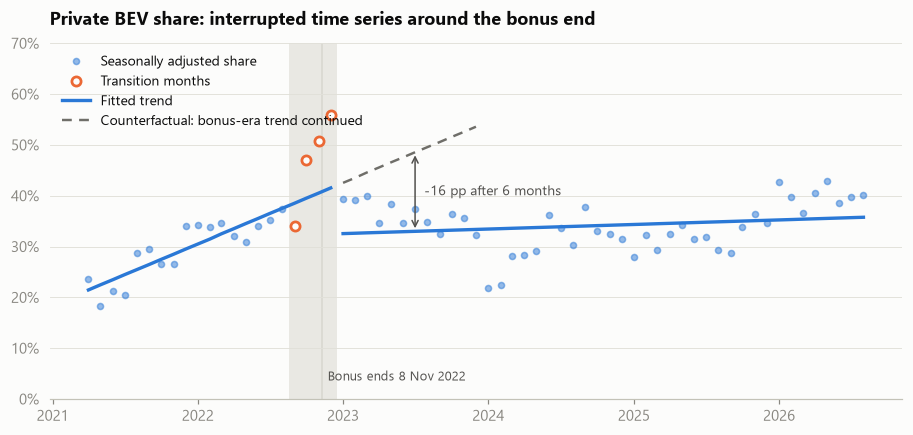

In [4]:
month_fx = pd.Series(0.0, index=range(1, 13))
for m in range(2, 13):
    month_fx[m] = main.params[f"m_{m}"]
month_fx -= month_fx.mean()                     # centre so trend lines represent an average month
adj = y - y.index.month.map(month_fx).values
b = main.params
base = b.const + main.params.filter(like="m_").sum() / 12
pre_idx, post_idx = y.index[y.index < T0], y.index[y.index >= T0]
t_of = pd.Series(X.t.values, index=y.index)
pre_line = base + b.t * t_of[pre_idx.union(TRANS)]
post_line = base + b.t * t_of[post_idx] + b.post + b.t_post * X.t_post[post_idx]
cf_idx = post_idx[:12]
cf_line = base + b.t * t_of[cf_idx]

fig, ax = plt.subplots()
ax.axvspan(TRANS[0] - pd.Timedelta(days=15), TRANS[-1] + pd.Timedelta(days=15), color=GRID, alpha=0.7, lw=0)
clean = ~y.index.isin(TRANS)
ax.plot(adj.index[clean], adj[clean], "o", color=BLUE, ms=4, alpha=0.5, label="Seasonally adjusted share")
ax.plot(TRANS, adj[TRANS], "o", ms=6, mfc=SURFACE, mec=ORANGE, mew=1.8, ls="none", label="Transition months")
ax.plot(pre_line.index, pre_line, color=BLUE, lw=2.2, label="Fitted trend")
ax.plot(post_line.index, post_line, color=BLUE, lw=2.2)
ax.plot(cf_line.index, cf_line, color=GREY_DARK, lw=1.6, ls=(0, (4, 3)), label="Counterfactual: bonus-era trend continued")
k = 6
ax.annotate("", xy=(cf_idx[k], post_line[cf_idx[k]]), xytext=(cf_idx[k], cf_line[cf_idx[k]]),
            arrowprops=dict(arrowstyle="<->", color=INK2, lw=1))
ax.annotate(f"{(post_line[cf_idx[k]] - cf_line[cf_idx[k]]) * 100:.0f} pp after 6 months", (cf_idx[k], (post_line[cf_idx[k]] + cf_line[cf_idx[k]]) / 2),
            xytext=(6, 0), textcoords="offset points", fontsize=9, color=INK2, va="center")
viz.mark_bonus(ax, y=0.08)
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, 0.7)
ax.set_title("Private BEV share: interrupted time series around the bonus end")
ax.legend(loc="upper left", fontsize=9)
viz.save(fig, "03_its_private", FIGS)
plt.show()

In [5]:
def effect_at(res, k, names=("post", "t_post")):
    # level + k * slope change, with its standard error from the covariance matrix
    p, V = res.params, res.cov_params()
    est = p[names[0]] + k * p[names[1]]
    se = np.sqrt(V.loc[names[0], names[0]] + k**2 * V.loc[names[1], names[1]] + 2 * k * V.loc[names[0], names[1]])
    return est * 100, se * 100

eff = pd.DataFrame([(k, *effect_at(main, k)) for k in [0, 6, 12, 24, 43]], columns=["months after Jan 2023", "effect (pp)", "SE"])
eff["95% CI"] = eff.apply(lambda r: f"[{r['effect (pp)'] - 1.96 * r.SE:+.1f}, {r['effect (pp)'] + 1.96 * r.SE:+.1f}]", axis=1)
eff["counterfactual share"] = [(base + b.t * (X.t[X.post == 1].iloc[0] + k)) for k in eff["months after Jan 2023"]]
eff.style.format({"effect (pp)": "{:+.1f}", "SE": "{:.1f}", "counterfactual share": "{:.0%}"}).hide(axis="index") \
   .set_caption("Implied effect of the bonus end vs the extrapolated bonus-era trend (main model)")

months after Jan 2023,effect (pp),SE,95% CI,counterfactual share
0,-10.0,3.5,"[-16.8, -3.2]",43%
6,-15.6,3.5,"[-22.5, -8.6]",49%
12,-21.1,3.8,"[-28.7, -13.6]",55%
24,-32.3,5.0,"[-42.0, -22.5]",67%
43,-49.9,7.5,"[-64.6, -35.3]",86%


**Reading the main model**
- **Bonus-era trend: +1.0 pp per month** (Apr 2021 – Aug 2022), very precisely estimated.
- **After Jan 2023 the trend is gone.** The slope change is −0.93 pp/month, which leaves an implied post-bonus trend of roughly **+0.1 pp/month**, essentially flat. This is the clearest result in the notebook.
- **Level change at Jan 2023: about −10 pp** compared with where the bonus-era trend would have been (95% CI −17 to −3 pp with HAC errors). Section 4 shows this part is *less* robust.

**Why the counterfactual stops after 12 months.** The table makes the problem clear. Extending +1 pp/month gives an "effect" of −32 pp after two years and −50 pp by Aug 2026, against a counterfactual share of about **67% in Jan 2025 and 86% in Aug 2026**. That isn't a credible no-policy world. The bonus era was the steep middle of an adoption S-curve, and it would have bent anyway as early adopters ran out, prices and interest rates changed, and supply normalised. So:
- the **short-run** effect (0–6 months: about −10 to −16 pp) is reasonably identified, because the counterfactual is close to the data;
- the **long-run** effect is **not identified** by this design. A long-run claim needs a different counterfactual, for example a comparison group or a saturating trend model. The honest headline is "the bonus end stopped the growth trend", not "the bonus end cost X pp by 2026".

**Jan–Feb 2024** are the largest negative residuals (about 22% seasonally adjusted, more than 10 pp below the post-bonus line). Nothing in this dataset explains them. It's worth checking whether a tax or policy change took effect at the turn of 2024 before 04 treats them as noise.

The residual diagnostics (Durbin–Watson well below 2, Ljung–Box p < 0.05) confirm strong autocorrelation. That's why HAC errors are used, and why section 4 re-estimates with AR(1) errors.

## 4. The rush before the deadline, and robustness

**The rush.** Each transition dummy measures how far that month's share sat **above the bonus-era trend plus its normal seasonal effect**. Multiplying by that month's private registrations converts it into **extra BEVs**. That number includes two kinds of buyer, and the data can't separate them:
- buyers who would have bought a BEV a few months later anyway (true pull-forward);
- buyers who chose a BEV instead of a combustion car to get the bonus while it lasted (net extra).

So it's an **upper bound on pull-forward**. The pre-trend is extrapolated only 1–4 months here, so this counterfactual is credible.

In [6]:
tr = main.params.filter(like="tr_")
rush = pd.DataFrame({"month": TRANS.strftime("%b %Y"), "share above trend (pp)": tr.values * 100,
                     "private registrations": pv.total.loc[TRANS].values})
rush["extra BEVs"] = rush["share above trend (pp)"] / 100 * rush["private registrations"]
rush.loc[len(rush)] = ["Sep–Dec total", np.nan, rush["private registrations"].sum(), rush["extra BEVs"].sum()]
bev22 = pv.bev.loc["2022"].sum()
drop23 = pv.bev.loc["2022-01":"2022-08"].sum() - pv.bev.loc["2023-01":"2023-08"].sum()
display(rush.style.format({"share above trend (pp)": "{:+.1f}", "private registrations": "{:,.0f}",
                           "extra BEVs": "{:+,.0f}"}, na_rep="").hide(axis="index"))
print(f"Extra BEVs Sep–Dec 2022 = {rush['extra BEVs'].iloc[-1]:,.0f}, i.e. {rush['extra BEVs'].iloc[-1] / bev22:.1%} of all "
      f"{bev22:,.0f} private BEVs in 2022.")
print(f"For scale: private BEVs fell by {drop23:,.0f} between Jan–Aug 2022 and Jan–Aug 2023.")

month,share above trend (pp),private registrations,extra BEVs
Sep 2022,-4.5,"9,305",-416
Oct 2022,+7.6,"9,352",+706
Nov 2022,+10.2,"10,061","+1,029"
Dec 2022,+14.3,"13,469","+1,922"
Sep–Dec total,,"42,187","+3,241"


Extra BEVs Sep–Dec 2022 = 3,241, i.e. 6.7% of all 48,726 private BEVs in 2022.
For scale: private BEVs fell by 6,145 between Jan–Aug 2022 and Jan–Aug 2023.


**The rush was real but small.** October to December 2022 ran about **8–14 pp above trend**. September sits *below* the line because its normal seasonal effect is large (01 found September about +8 pp above trend in a typical year). Net, Sep–Dec 2022 had roughly **3,200 extra BEVs**, about **7% of 2022's private BEVs**.

For comparison, private BEV registrations fell by about **6,100** between Jan–Aug 2022 and Jan–Aug 2023. Even if every one of the extra autumn BEVs was a purchase pulled forward from 2023, that explains only about half of the 2023 shortfall. The bigger story is the **broken trend** and the **shrinking private market**, not buyers rushing ahead.

### Robustness
Each row changes one choice and re-estimates the level change (pp at Jan 2023) and the slope change (pp/month):
- **AR(1) errors:** models the autocorrelation directly instead of correcting the standard errors.
- **Logit share:** the effect is converted back to pp at Jan 2023, which respects the 0–1 bound.
- **Start Jan 2021:** includes the pre-April-2021 regime.
- **Shorter transition (Sep–Nov):** the build script's original window, so Dec 2022 counts as post-period.
- **Longer transition (Sep 2022 – Mar 2023):** also treats the Q1 2023 hangover as transition.

In [7]:
def row(name, res, logit=False, y_=None, X_=None):
    if logit:
        x0 = X_.loc[T0]
        with_ = 1 / (1 + np.exp(-(x0 @ res.params)))
        without = 1 / (1 + np.exp(-(x0 @ res.params - res.params.post)))
        lvl, lvl_se = (with_ - without) * 100, np.nan
        slope = res.params.t_post * with_ * (1 - with_) * 100
        return name, lvl, lvl_se, slope, np.nan
    l, lse = res.params.post * 100, res.bse.post * 100
    return name, l, lse, res.params.t_post * 100, res.bse.t_post * 100

ar1, _, _ = fit_its(pv.share, errors="ar1")
lg_y, lg_X = its_design(np.log(pv.share / (1 - pv.share)))
lg = sm.OLS(lg_y, lg_X).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
rob = pd.DataFrame([
    row("Main (OLS, HAC)", main),
    row("AR(1) errors", ar1),
    row("Logit share (pp at Jan 2023)", lg, logit=True, X_=lg_X),
    row("Start Jan 2021", fit_its(pv.share, start=pd.Timestamp("2021-01-01"))[0]),
    row("Transition Sep–Nov 2022", fit_its(pv.share, trans=TRANS[:3])[0]),
    row("Transition Sep 2022–Mar 2023", fit_its(pv.share, trans=pd.date_range("2022-09-01", "2023-03-01", freq="MS"))[0]),
], columns=["specification", "level change (pp)", "SE", "slope change (pp/mo)", "SE "])
print(f"AR(1) coefficient: {ar1.params['ar.L1']:.2f}")
rob.style.format({"level change (pp)": "{:+.1f}", "SE": "{:.1f}", "slope change (pp/mo)": "{:+.2f}", "SE ": "{:.2f}"},
                 na_rep="–").hide(axis="index")

AR(1) coefficient: 0.57


specification,level change (pp),SE,slope change (pp/mo),SE
"Main (OLS, HAC)",-10.0,3.5,-0.93,0.16
AR(1) errors,-10.8,8.6,-0.97,0.54
Logit share (pp at Jan 2023),-12.1,–,-1.03,–
Start Jan 2021,-14.3,4.2,-1.36,0.24
Transition Sep–Nov 2022,-13.9,3.7,-1.19,0.26
Transition Sep 2022–Mar 2023,-12.8,3.6,-0.88,0.18


**What survives**
- **The slope change is robust.** Every specification puts it at about −0.9 to −1.4 pp/month, which turns a +1 pp/month climb into a flat line. It's significant at 5% everywhere except the AR(1) model, where p ≈ 0.07. "The bonus end stopped the growth trend" holds whichever way it's estimated.
- **The level change is consistent in size but imprecise.** Every point estimate is a drop of **10–14 pp**. With AR(1) errors, though, the standard error more than doubles (8.6 pp) and the interval includes zero. The estimate also moves by about 4 pp with the choice of window. "An immediate drop of around 10 pp" is plausible, but the data can't pin it down precisely.
- **The logit version** gives effects of the same size in pp. The linear model isn't being distorted by the 0–1 bound in this range.

## 5. Who was affected? Companies, and dense vs sparse counties

### 5a. Private vs company buyers
01 showed company buyers overtaking private buyers on BEV share in 2023. A natural idea is to use companies as a **comparison group** (difference-in-differences). That works only if company buyers were *unaffected* by the bonus end and would otherwise have followed the same trend as private buyers. The chart checks this.

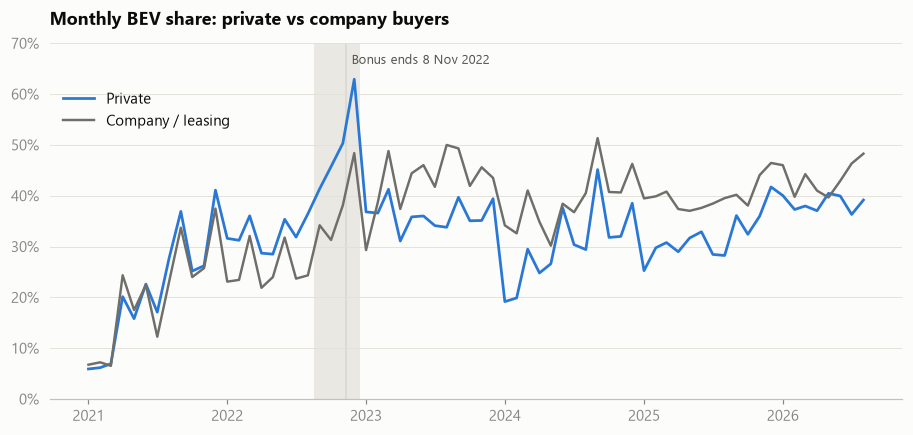

,private,company,gap private − company (pp)
Apr 2021–Aug 2022,29.0%,25.0%,+4.0
Jan–Jun 2023,36.3%,40.8%,-4.5
2023–Aug 2026,33.9%,41.2%,-7.3


Company ITS: pre-trend +0.36 pp/mo, level change +10.5 pp (p = 0.001), slope change -0.32 pp/mo


In [8]:
co = own["company"]
fig, ax = plt.subplots()
ax.axvspan(TRANS[0] - pd.Timedelta(days=15), TRANS[-1] + pd.Timedelta(days=15), color=GRID, alpha=0.7, lw=0)
ax.plot(pv.index, pv.share, color=BLUE, lw=1.8, label="Private")
ax.plot(co.index, co.share, color=GREY_DARK, lw=1.6, label="Company / leasing")
viz.mark_bonus(ax)
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, 0.7)
ax.set_title("Monthly BEV share: private vs company buyers")
ax.legend(loc="upper left", bbox_to_anchor=(0, 0.9))
viz.save(fig, "03_private_vs_company", FIGS)
plt.show()

periods = {"Apr 2021–Aug 2022": ("2021-04", "2022-08"), "Jan–Jun 2023": ("2023-01", "2023-06"),
           "2023–Aug 2026": ("2023-01", None)}
cmp = pd.DataFrame({p: {"private": pv.share.loc[a:b].mean(), "company": co.share.loc[a:b].mean()} for p, (a, b) in periods.items()}).T
cmp["gap private − company (pp)"] = (cmp.private - cmp.company) * 100
display(cmp.style.format({"private": "{:.1%}", "company": "{:.1%}", "gap private − company (pp)": "{:+.1f}"})
           .set_caption("Mean monthly BEV share by period"))

co_its, _, _ = fit_its(co.share)
print(f"Company ITS: pre-trend {co_its.params.t * 100:+.2f} pp/mo, level change {co_its.params.post * 100:+.1f} pp "
      f"(p = {co_its.pvalues.post:.3f}), slope change {co_its.params.t_post * 100:+.2f} pp/mo")

**Companies aren't a clean comparison group.** The company BEV share didn't just "continue its trend". It **jumped from about 25% to over 40%** across the same boundary, a level shift as large as the private drop but in the opposite direction. The private-minus-company gap swung from about **+4 pp to −7 pp**, but this can't be read as a causal estimate. Something pushed company BEV adoption *up* at the same moment, or the boundary changed which cars were registered as company cars (for example leasing structures). Neither is visible in this data.

What can be said: **private buyers are the group whose BEV adoption stalled**. Company buyers, who respond more to running costs and company-car taxation than to the purchase price, kept going. That matches 01, and it means the national all-owner share (which mixes both groups) hides how sharply private adoption stalled.

### 5b. Dense vs sparse counties (dose–response)
02 found that sparsely populated counties lost more after the bonus and are rebounding faster. Here the ITS is estimated on **county × month** data (21 counties, transition months removed):

$$y_{ct} = \alpha_c + \gamma_t + \delta_1\,(d_c \cdot t) + \delta_2\,(d_c \cdot \text{post}_t) + \delta_3\,(d_c \cdot (t-T_0)\,\text{post}_t) + \varepsilon_{ct}$$

- $\alpha_c$ = county fixed effects. $\gamma_t$ = **month fixed effects**, which absorb the whole national pattern, including the bonus effect and seasonality.
- $d_c$ = centred log density. The $\delta$s measure how the pre-trend, the level change and the slope change **differ with density**.
- Errors are clustered by county. Both an unweighted and a registration-weighted version are shown.

In [9]:
dens = panel[panel.year == 2025].set_index("county_code").pop_per_km2
f = fact[(fact.owner_type == "private") & (fact.county_code != "99")]
w = f.pivot_table(index=["county_code", "month"], columns="fuel_type", values="registrations", aggfunc="sum", fill_value=0)
cm = pd.DataFrame({"y": w["BEV"] / w.sum(axis=1), "n": w.sum(axis=1)}).reset_index()
cm = cm[(cm.month >= START) & ~cm.month.isin(TRANS)].copy()
cm["d"] = np.log(cm.county_code.map(dens))
cm["d"] -= cm.d.mean()
cm["t"] = (cm.month.dt.year - START.year) * 12 + cm.month.dt.month - START.month
cm["post"] = (cm.month >= T0).astype(int)
cm["t_post"] = np.where(cm.post == 1, (cm.month.dt.year - T0.year) * 12 + cm.month.dt.month - T0.month, 0)

DR = {"d:t": "pre-trend (pp/mo)", "d:post": "level change (pp)", "d:t_post": "slope change (pp/mo)"}
out = {}
for name, kw in [("unweighted", {}), ("weighted by registrations", {"weights": cm.n})]:
    mod = (smf.wls if kw else smf.ols)("y ~ C(county_code) + C(month) + d:t + d:post + d:t_post", cm, **kw)
    r = mod.fit(cov_type="cluster", cov_kwds={"groups": cm.county_code})
    out[name] = {DR[k]: f"{r.params[k] * 100 * np.log(2):+.2f} (p={r.pvalues[k]:.3f})" for k in DR}
pd.DataFrame(out).style.set_caption("Effect of 2× population density on each ITS component (county × month, month FE)")

,unweighted,weighted by registrations
pre-trend (pp/mo),-0.06 (p=0.022),-0.07 (p=0.000)
level change (pp),+0.22 (p=0.518),+1.19 (p=0.004)
slope change (pp/mo),+0.10 (p=0.003),+0.08 (p=0.000)


**Reading the dose–response model** (each number is per *doubling* of density)
- **Before the bonus ended, sparse counties were catching up.** The density × pre-trend term is negative (about −0.06 pp/month per doubling, significant in both versions), so less dense counties gained share slightly faster.
- **After it ended, that reversed.** The slope-change term is positive (about +0.08 to +0.10 pp/month, p < 0.01), larger than the pre-trend term. Over 2023–26 the denser counties drifted ahead, and the catch-up by sparse counties stopped.
- **Level change:** about +1.2 pp per doubling in the weighted model (p < 0.01), but small and insignificant unweighted. The weighted version is driven by the large urban counties, so the immediate-drop difference is uncertain. The trend difference is consistent across both.
- **Caveat:** a linear post-trend can't capture the shape 02 found, a deeper fall in sparse counties during 2024 followed by a stronger rebound in 2026. The dose–response averages over that V-shape. Both views agree that **sparse counties were the most dependent on the bonus**.

## 6. Summary: what did ending the bonus do?

1. **It stopped the growth trend.** Private BEV share was rising about **+1 pp per month** under the bonus. After Jan 2023 the trend went flat (+0.07 pp/month) for almost three years. The slope change is −0.9 to −1.4 pp/month in every specification.
2. **The immediate drop is plausible but imprecise.** Point estimates are 10–14 pp at Jan 2023, but with AR(1) errors the interval includes zero. Report "around 10 pp, statistically fragile", not a precise figure.
3. **The rush was small.** About 3,200 extra BEVs in Sep–Dec 2022 (~7% of the 2022 private BEV volume). At most it explains half of the 2023 decline in private BEV volume.
4. **The long-run "cost" isn't identified.** Extending the bonus-era trend implies 67% BEV share by early 2025 and 86% by Aug 2026, which isn't credible. The design supports short-run statements only.
5. **Private buyers bore the change.** Company buyers' BEV share *rose* across the same boundary, so they can't serve as a control, but the contrast shows the bonus mattered most to private buyers.
6. **Sparse counties were the most bonus-dependent.** Their pre-bonus catch-up stopped once the bonus ended.

**For 04 · Forecast**
- **Model the regime explicitly.** Fit the forecast on the **post-bonus period (2023 onwards)**, or include the regime change as a known break. Training on 2021–22 would carry the bonus-era growth rate forward.
- The post-bonus series is flat for 2023–25 and then rising from late 2025. The forecast has to decide how much weight the most recent 10–12 months get. **Scenarios** (plateau / current momentum / S-curve catch-up) are more honest than a single line.
- **Residual autocorrelation** is strong (DW ≈ 0.8). Forecast intervals from a model that ignores it will be too narrow.